# Exploring the bundled material library

Peritheos distributes a versioned `.eosmat` library in addition to its compact
pressure-scale convenience catalog. This notebook discovers the full library,
summarizes its model coverage, inspects provenance, and converts one document
into executable EOS records.

All operations are offline: the material documents, schema, and audit metadata
are installed with the package.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt

from peritheos import Material, get_material_document, list_material_documents

plt.style.use("seaborn-v0_8-whitegrid")

material_ids = list_material_documents()
documents = [get_material_document(identifier) for identifier in material_ids]
records = [record for document in documents for record in document["eos_records"]]

print(f"Material documents: {len(documents)}")
print(f"EOS records: {len(records)}")
print(
    f"Records with a thermal component: {sum(r.get('thermal') is not None for r in records)}"
)
print("First ten identifiers:", ", ".join(material_ids[:10]))

Material documents: 115
EOS records: 147
Records with a thermal component: 28
First ten identifiers: akimotoite, almandine, alpha_quartz, alumina, aluminum, aragonite, argon_hcp, b4c, boron_nitride, boron_nitride_hexagonal


## Summarize equation coverage

The equation discriminator lives inside each record's `eos` component. Thermal
components are counted separately because they compose with a reference
isotherm rather than replacing it.

In [2]:
isothermal_counts = Counter(record["eos"]["model"] for record in records)
thermal_counts = Counter(
    record["thermal"]["model"]
    for record in records
    if record.get("thermal") is not None
)

print("Isothermal models:")
for model, count in isothermal_counts.most_common():
    print(f"  {model:42s} {count:3d}")

print("\nThermal models:")
for model, count in thermal_counts.most_common():
    print(f"  {model:42s} {count:3d}")

Isothermal models:
  birch_murnaghan_3                           67
  vinet                                       47
  birch_murnaghan_2                           18
  holzapfel                                   11
  murnaghan                                    3
  birch_murnaghan_4                            1

Thermal models:
  multi_oscillator_gruneisen_thermal_pressure  11
  mie_gruneisen_debye                          9
  thermal_reference_state                      3
  linear_thermal_pressure                      3
  double_debye_helmholtz                       1
  log_volume_thermal_pressure                  1


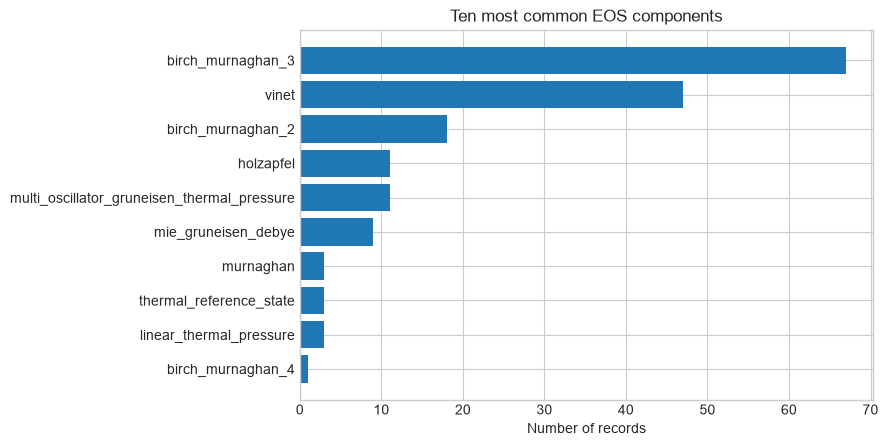

In [3]:
model_labels = []
model_values = []
for model, count in (isothermal_counts + thermal_counts).most_common(10):
    model_labels.append(model)
    model_values.append(count)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.barh(model_labels[::-1], model_values[::-1])
ax.set(xlabel="Number of records", title="Ten most common EOS components")
plt.show()

## Search by scientific metadata

Documents are ordinary defensive-copy dictionaries, so searches can use the
material formula, phase, model, reference, or any other stored field. This
query finds every material document containing gold.

In [4]:
matches = [document for document in documents if document["formula"] == "Au"]
for document in matches:
    print(
        f"{document['identifier']}: {document['name']} "
        f"({len(document['eos_records'])} records)"
    )
    for record in document["eos_records"]:
        thermal = record.get("thermal")
        thermal_name = thermal["model"] if thermal is not None else "none"
        validation = record["scientific_validation"]["status"]
        print(
            f"  {record['identifier']}\n"
            f"    cold={record['eos']['model']}, thermal={thermal_name}\n"
            f"    validation={validation}, DOI={record['reference'].get('doi')}"
        )

gold: Gold (4 records)
  gold_anderson_1989_bm3_1
    cold=birch_murnaghan_3, thermal=log_volume_thermal_pressure
    validation=primary_source_validated, DOI=10.1063/1.342969
  gold_fei_2007_vinet_2
    cold=vinet, thermal=mie_gruneisen_debye
    validation=primary_source_validated, DOI=10.1073/pnas.0609013104
  gold_shen_2026_vinet_3
    cold=vinet, thermal=none
    validation=primary_source_validated, DOI=10.1103/fxgq-96sg
  gold_sokolova_2013_holzapfel_4
    cold=holzapfel, thermal=multi_oscillator_gruneisen_thermal_pressure
    validation=primary_source_validated, DOI=10.1016/j.rgg.2013.01.005


## Inspect the shared structural and EOS document

The crystallographic information and EOS records belong to one flat material
document. Peritheos preserves structure fields for interoperability even
though pressure calculations use only the material's cell definition and EOS.

In [5]:
gold_document = get_material_document("gold")
print("Document format:", gold_document["format"], gold_document["format_version"])
print("Formula:", gold_document["formula"])
print("Symmetry:", gold_document.get("symmetry"))
print("Space group:", gold_document.get("space_group"))
print("Formula units per cell:", gold_document.get("formula_units_per_cell"))
print("Lattice:", gold_document.get("lattice"))
print("Atom sites:", gold_document.get("atom_sites"))

Document format: peritheos.material 3
Formula: Au
Symmetry: CUBIC
Space group: Fm-3m
Formula units per cell: 4
Lattice: {'a': 4.0862, 'b': None, 'c': None, 'alpha': 90.0, 'beta': 90.0, 'gamma': 90.0}
Atom sites: [{'element': 'Au', 'wyckoff': '4a', 'x': 0.0, 'y': 0.0, 'z': 0.0, 'occupancy': 1.0}]


## Construct and use an executable record

`Material.from_eosmat` validates model discriminators and creates the EOS
objects. Selecting by stable record identifier keeps the exact source and
parameterization attached to the calculation.

In [6]:
gold = Material.from_eosmat(gold_document)
print("Executable records:")
for record in gold.eos_records:
    print(f"  {record.identifier}: {record.name}")

fei = gold.get_eos_record("gold_fei_2007_vinet_2")
pressure = fei.pressure(volume=55.0, temperature=1800.0)
print(f"\nFei Au at V=55.0 A^3 and T=1800 K: {pressure:.3f} GPa")
print("Within stored validity:", fei.within_validity(55.0, 1800.0))
print("Source DOI:", fei.reference.doi)

Executable records:
  gold_anderson_1989_bm3_1: Anderson et al. (1989), Au logarithmic-volume thermal EOS
  gold_fei_2007_vinet_2: 04-0784, Fei et al PNAS, 2007 [Vinet]
  gold_shen_2026_vinet_3: Shen and Smith (2026), Cu-referenced Vinet
  gold_sokolova_2013_holzapfel_4: Sokolova et al. (2013), Holzapfel thermal model (2016 workbook)

Fei Au at V=55.0 A^3 and T=1800 K: 76.410 GPa
Within stored validity: True
Source DOI: 10.1073/pnas.0609013104


## Takeaways

1. Use `list_material_documents` for complete-library discovery.
2. Search raw documents before constructing only the records an analysis needs.
3. Stable material and record identifiers make calculations reproducible.
4. Provenance, validation, units, structure, and numerical parameters travel
   together in the `.eosmat` document.